In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("C:/Users/muham/Desktop/Tahniyat_code/Task_5/bank_EDA_processed.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (45211, 17)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome  y  
0  unknown    5   may       261         1     -1         0  unknown  0  
1  unknown    5   may       151         1     -1         0  unknown  0  
2  unknown    5   may        76         1     -1         0  unknown  0  
3  unknown    5   may        92         1     -1         0  unknown  0  
4  unknown    5   may       198         1     -1         0  unknown  0  


In [3]:
# Preprocessing
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("\nCategorical Columns:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop("y", axis=1)
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)


Categorical Columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Train size: (36168, 16)
Test size: (9043, 16)


C:\Users\muham\AppData\Local\Temp\ipykernel_19876\1328292483.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


In [4]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("\n--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))


--- Logistic Regression ---
Accuracy: 0.8854362490324007
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7952
           1       0.57      0.21      0.30      1091

    accuracy                           0.89      9043
   macro avg       0.73      0.59      0.62      9043
weighted avg       0.86      0.89      0.86      9043



c:\Users\muham\anaconda3\envs\mlTask\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [5]:
# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("\n--- Decision Tree ---")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))


--- Decision Tree ---
Accuracy: 0.8935087913303107
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7952
           1       0.59      0.40      0.48      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.68      0.71      9043
weighted avg       0.88      0.89      0.88      9043



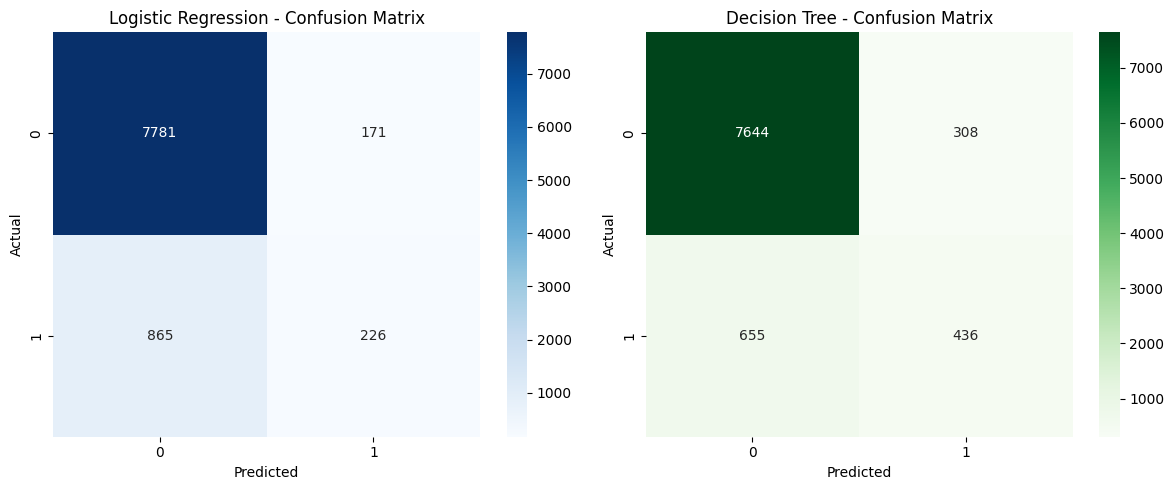

In [6]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt="d",
            ax=axes[0], cmap="Blues")
axes[0].set_title("Logistic Regression - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt="d",
            ax=axes[1], cmap="Greens")
axes[1].set_title("Decision Tree - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

C:\Users\muham\AppData\Local\Temp\ipykernel_19876\554905708.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance.values, y=feat_importance.index, palette="viridis")


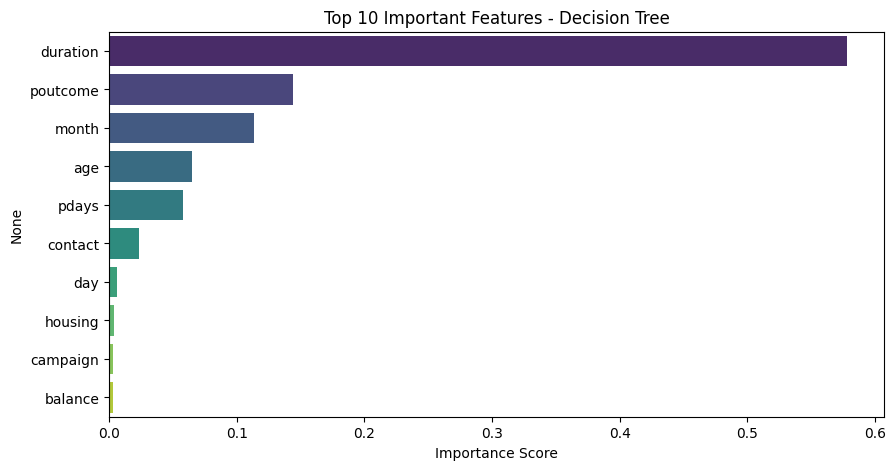


Top Features:
 duration    0.578134
poutcome    0.144215
month       0.113463
age         0.065036
pdays       0.057855
contact     0.023506
day         0.006439
housing     0.003712
campaign    0.003335
balance     0.002783
dtype: float64


In [7]:
# Feature 
feat_importance = pd.Series(dt_model.feature_importances_, 
                             index=X.columns)
feat_importance = feat_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette="viridis")
plt.title("Top 10 Important Features - Decision Tree")
plt.xlabel("Importance Score")
plt.show()

print("\nTop Features:\n", feat_importance)

C:\Users\muham\AppData\Local\Temp\ipykernel_19876\3419148701.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_acc.index, y=job_acc.values, palette="magma")


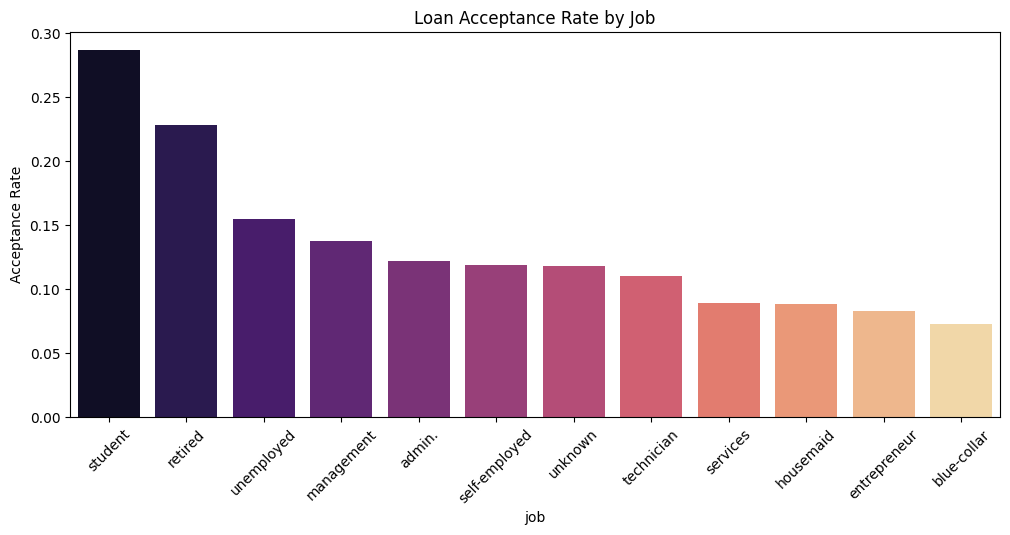

In [8]:
# CUSTOMER GROUP ANALYSIS
df_original = pd.read_csv("C:/Users/muham/Desktop/Tahniyat_code/Task_5/bank-full.csv", sep=";")  # original file
df_processed = pd.read_csv("C:/Users/muham/Desktop/Tahniyat_code/Task_5/bank_EDA_processed.csv")            # processed file

# y column original mein add karo
df_original["accepted"] = df_processed["y"]

# Job Group
plt.figure(figsize=(12, 5))
job_acc = df_original.groupby("job")["accepted"].mean().sort_values(ascending=False)
sns.barplot(x=job_acc.index, y=job_acc.values, palette="magma")
plt.title("Loan Acceptance Rate by Job")
plt.xticks(rotation=45)
plt.ylabel("Acceptance Rate")
plt.show()

C:\Users\muham\AppData\Local\Temp\ipykernel_19876\2613091673.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_acc.index, y=age_acc.values, palette="coolwarm")


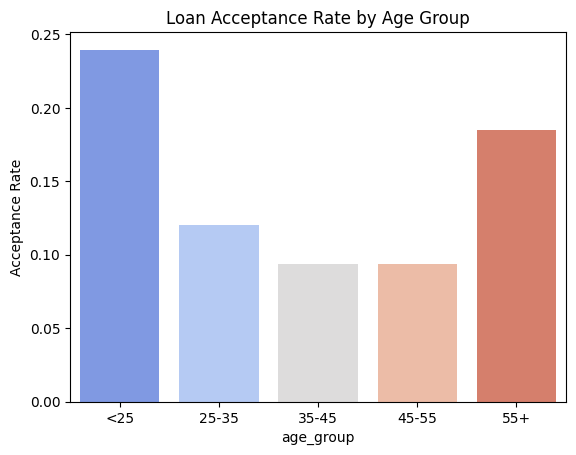

In [9]:
 
df_original["age_group"] = pd.cut(df_original["age"],
                                   bins=[0, 25, 35, 45, 55, 100],
                                   labels=["<25", "25-35", "35-45", "45-55", "55+"])
plt.figure()
age_acc = df_original.groupby("age_group", observed=True)["accepted"].mean()
sns.barplot(x=age_acc.index, y=age_acc.values, palette="coolwarm")
plt.title("Loan Acceptance Rate by Age Group")
plt.ylabel("Acceptance Rate")
plt.show()

C:\Users\muham\AppData\Local\Temp\ipykernel_19876\4046025062.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=marital_acc.index, y=marital_acc.values, palette="Set2")


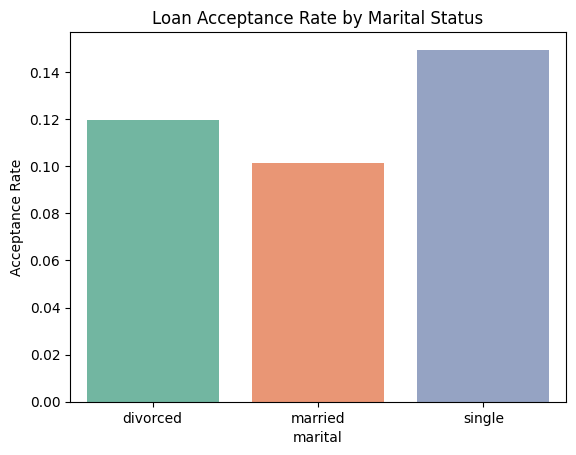

In [10]:
plt.figure()
marital_acc = df_original.groupby("marital")["accepted"].mean()
sns.barplot(x=marital_acc.index, y=marital_acc.values, palette="Set2")
plt.title("Loan Acceptance Rate by Marital Status")
plt.ylabel("Acceptance Rate")
plt.show()


In [11]:
joblib.dump(lr_model, "logistic_model.pkl")
joblib.dump(dt_model, "decision_tree_model.pkl")
print("\nModels saved successfully!")


Models saved successfully!
